In [1]:
from quspin.operators import hamiltonian 
from quspin.basis import spin_basis_1d, spinless_fermion_basis_1d  # type: ignore
from quspin.tools.measurements import mean_level_spacing, ent_entropy # Nice feature to compute Quantum Mechanics things
from scipy.sparse.linalg import eigsh  # Sparse eigenvalue solver: Very important for efficiency!!
import numpy as np # As usual in Python
import math
import matplotlib.pyplot as plt # Plotting library 

\begin{equation}
\begin{aligned}
H
=&
\sum_{i=0}^{L-1}
j_1\left(\alpha+(-1)^i\right)
\Big[
\cosh^2\beta
-\sinh\beta\cosh\beta\,\sigma_i^x
-\sinh\beta\cosh\beta\,\sigma_{i+1}^x
+\sinh^2\beta\,\sigma_i^x\sigma_{i+1}^x
-\sigma_i^z\sigma_{i+1}^z
\Big]
\\
&
+\sum_{i=0}^{L-1}
j_2\left(\alpha+(-1)^i\right)
\Big[
\cosh^2\beta
+\sinh^2\beta\,\sigma_{i-1}^z\sigma_{i+1}^z
-\sinh\beta\cosh\beta\,\sigma_i^z\sigma_{i+1}^z
-\sinh\beta\cosh\beta\,\sigma_{i-1}^z\sigma_i^z
-\sigma_i^x
\Big]
\\
&
-h_x\sum_{i=0}^{L-1}\sigma_i^x
-h_z\sum_{i=0}^{L-1}\sigma_i^z
-h_{zz}\sum_{i=0}^{L-1}\sigma_i^z\sigma_{i+1}^z.
\end{aligned}
\end{equation}

In [2]:
# Function to define Hamiltonian
def h_scars(j1,j2,L,alpha,beta,hx,hz,hzz,base):

# Primal Model
    a0 = [[j1*(alpha+(-1)**i)*(np.cosh(beta))**2, i] for i in range(L)]
    a1 = [[-j1*(alpha+(-1)**i)*np.sinh(beta)*np.cosh(beta), i] for i in range(L)]
    a2 = [[-j1*(alpha+(-1)**i)*np.sinh(beta)*np.cosh(beta), (i+1)%L] for i in range(L)]
    a3 = [[j1*(alpha+(-1)**i)*(np.sinh(beta))**2, i, (i+1)%L] for i in range(L)]
    a4 = [[-j1*(alpha+(-1)**i), i, (i+1)%L] for i in range(L)]

# Dual model 
    b0 = [[j2*(alpha+(-1)**i)*(np.cosh(beta))**2, i] for i in range(L)]
    b1 = [[j2*(alpha+(-1)**i)*(np.sinh(beta))**2, (i-1)%L, (i+1)%L] for i in range(L)]
    b2 = [[-j2*(alpha+(-1)**i)*np.sinh(beta)*np.cosh(beta), i, (i+1)%L] for i in range(L)]
    b3 = [[-j2*(alpha+(-1)**i)*np.sinh(beta)*np.cosh(beta), (i-1)%L, i] for i in range(L)]
    b4 = [[-j2*(alpha+(-1)**i), i] for i in range(L)]    

    # Symmetry Breaking Perturbations
    pertx = [[-hx, i] for i in range(L)]
    pertzz = [[-hzz, i,(i+1)%L] for i in range(L)]
    pertz=[[-hz, i] for i in range(L)]

    static_spin = [['I', a0], ['x', a1], ['x', a2], ['xx', a3], ['zz', a4],['I', b0], ['zz', b1], ['zz', b2], ['zz', b3], ['x', b4],['x', pertx], ['zz', pertzz], ['z', pertz]]
    dynamic_spin = []

    H = hamiltonian(static_spin, dynamic_spin, basis=base,check_herm=False, check_symm=False, dtype=np.float64)
    return H

In [4]:
#Define all the parameters
L = 10
alpha = 0.3
beta = 0.5
j1=1.0
j2=0
hx=0.00
hz=0.05
hzz=0.0

full_basis = spin_basis_1d(L, pauli=True)
basis_even = spin_basis_1d(L, zblock=1, pauli=True)
basis_odd = spin_basis_1d(L, zblock=-1, pauli=True)

In [5]:
energie0, states0=h_scars(j1,0,L,alpha,beta,0,0,0,full_basis).eigh()

In [6]:
energie0_odd, states0_odd=h_scars(j1,0,L,alpha,beta,0,0,0,basis_odd).eigh()
energie0_even, states0_even=h_scars(j1,0,L,alpha,beta,0,0,0,basis_even).eigh()

In [ ]:
# First we need to set the scars states in the degenerate regime by hand. We look for energy 0 states with the lowest entanglement entropy.

In [7]:
# sort spectrum
idx = np.argsort(energie0)
energies = energie0[idx]
states = states0[:, idx]

# locate zero-energy scar states
scar_idx = np.where(np.abs(energies) < 1e-10)[0]

scar1 = states[:, scar_idx[0]]
scar2 = states[:, scar_idx[1]]

In [8]:
# Global Z2 operator \eta = X_0 X_1 ... X_{L-1}
def string_x(L):
    sx=np.array([[0,1],[1,0]])
    op=sx
    for _ in range(L-1):
        op=np.kron(op,sx)
    return op

In [9]:
# Here we check the symmetry sector of the zero-energy eigentstates, we should expect that this returns zero because the Quspin eigh is not symmetry resolved.
Eta = string_x(L)

for name, psi in zip(
    ["scar1", "scar2", "scar_plus", "scar_minus"],
    [scar1, scar2],
):
    Etapsi = Eta @ psi
    lam = np.vdot(psi, Etapsi)
    err = np.linalg.norm(Etapsi - lam*psi)

    print(name)
    print("eigenvalue =", lam)
    print("error      =", err)

scar1
eigenvalue = 0.0003897750189201507
error      = 0.9999999240377156
scar2
eigenvalue = -0.00038977501892015226
error      = 0.9999999240377137


In [10]:
#For your later defect insertion analysis, I would definitely keep this step: always resolve the degenerate scar manifold into irreducible Z2 representations before comparing states.
S = np.column_stack((scar1, scar2))

# symmetry matrix in zero-energy subspace
Eta_sub = S.conj().T @ (Eta @ S)

print(Eta_sub)

vals, vecs = np.linalg.eigh(Eta_sub)

print("Z2 eigenvalues:", vals)

[[ 3.89775019e-04  9.99999924e-01]
 [ 9.99999924e-01 -3.89775019e-04]]
Z2 eigenvalues: [-1.  1.]


In [11]:
# define the scars states based on Z2 symmetry
scar_minus = S @ vecs[:,0]
scar_plus  = S @ vecs[:,1]

In [12]:
# Test Symm sectors
print(np.vdot(scar_minus, Eta @ scar_minus))
print(np.vdot(scar_plus, Eta @ scar_plus))

-1.0
1.0000000000000002


In [13]:
# bipartite entanglement
sub_A = list(range(L//2))
entropies = np.array([
    ent_entropy(states[:, i], full_basis, chain_subsys=sub_A)["Sent_A"]
    for i in range(states.shape[1])
])

In [14]:
# Now we diagonalize the Hamiltonian considering the perturbations breaking the Z2 symmetry
pert_energies, pert_states=h_scars(j1,j2,L,alpha,beta,hx,hz,hzz,full_basis).eigh()

In [15]:
# bipartite entanglement with perturbed eigenstates
sub_A = list(range(L//2))
pert_entropies = np.array([
    ent_entropy(pert_states[:, i], full_basis, chain_subsys=sub_A)["Sent_A"]
    for i in range(pert_states.shape[1])
])

In [16]:
#Plotting entropy with the symmetry breaking perturbations. Set the style of the plot
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
})

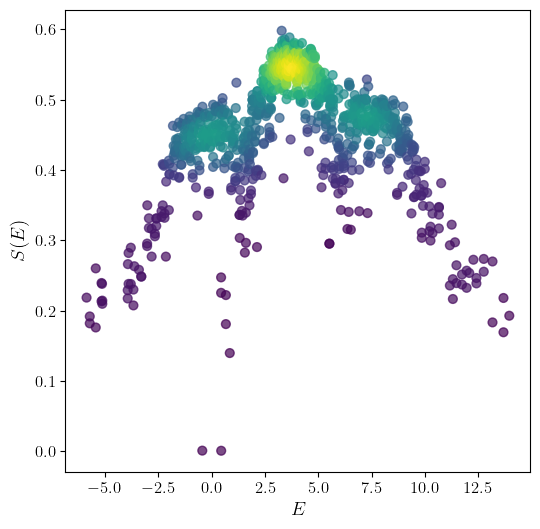

In [108]:
from scipy.stats import gaussian_kde
# Calculate point density for the entire plot area
xy = np.vstack([pert_energies, pert_entropies])
density = gaussian_kde(xy)(xy)

# Plotting
plt.figure(figsize=(6, 6))
plt.scatter(pert_energies, pert_entropies, c=density, s=40, cmap='viridis', alpha=0.7)

# Labels and title with LaTeX formatting
plt.xlabel(r"$E$", fontsize=14)
plt.ylabel(r"$S(E)$", fontsize=14)

plt.grid(False)
plt.show()

In [17]:
# Setting energy window to get low entangled states = new scars candidates
idx_window = np.where(np.abs(pert_energies)<2*hz)[0]

In [18]:
entropy_window = entropies[idx_window]

candidate_idx = idx_window[np.argsort(entropy_window)[:2]]

In [19]:
#3. The more robust method: overlap with the original scar manifold Since you know the scar subspace at hz=0

S0 = np.column_stack((scar_plus, scar_minus))

weights = np.array([
    np.sum(np.abs(S0.conj().T @ pert_states[:,n])**2)
    for n in range(pert_states.shape[1])
])

In [20]:
scar_candidates = np.argsort(weights)[-2:]

In [21]:
from quspin.tools.measurements import ED_state_vs_time
time_len = np.linspace(0,18,200)

state_plus_t = ED_state_vs_time(
    scar_plus,
    pert_energies,
    pert_states,
    time_len,
    iterate=False
)

state_minus_t = ED_state_vs_time(
    scar_minus,
    pert_energies,
    pert_states,
    time_len,
    iterate=False
)

echo_plus = np.abs(scar_plus.conj() @ state_plus_t)**2
echo_minus = np.abs(scar_minus.conj() @ state_minus_t)**2

In [22]:
rng = np.random.default_rng(2**L)

thermal_state = (
    rng.normal(size=full_basis.Ns)
    + 1j*rng.normal(size=full_basis.Ns)
)

thermal_state /= np.linalg.norm(thermal_state)

thermal_state_t = ED_state_vs_time(
    thermal_state,
    pert_energies,
    pert_states,
    time_len,
    iterate=False
)

echo_thermal = np.abs(thermal_state.conj() @ thermal_state_t)**2

In [ ]:
import numpy as np

data = np.column_stack([time_len, echo_plus, echo_minus, echo_thermal])
np.savetxt(
    "LS_Echo_two_level_dynamics.csv",
    data,
    delimiter=",",
    header="t,echo_plus,echo_minus,echo_thermal",
    comments="",
)

In [13]:
time_len, echo_plus, echo_minus, echo_thermal = np.loadtxt("LS_Echo_two_level_dynamics.csv", delimiter=",", skiprows=1, unpack=True)

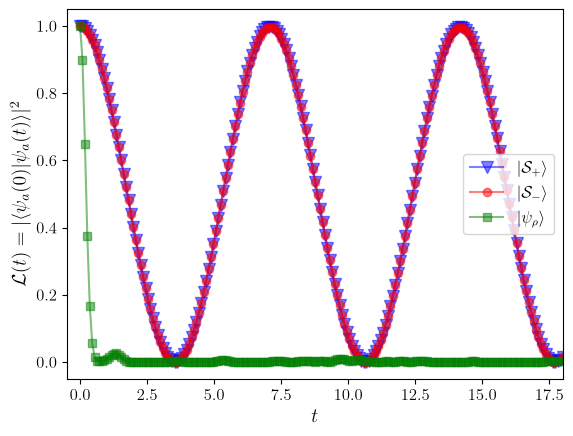

In [15]:
#plt.figure(figsize=(10, 6), dpi=300)

plt.plot(time_len, echo_plus , color="blue", alpha=0.5,marker='v', markersize=8, label=r"$|\mathcal{S}_+\rangle$")
plt.plot(time_len, echo_minus , color="red",  alpha=0.5,marker='o', markersize=6, label=r"$|\mathcal{S}_-\rangle$")
plt.plot(time_len, echo_thermal , color="green", alpha=0.5,marker='s', markersize=6, label=r"$|\psi_\rho\rangle$")



# Labels and title with LaTeX formatting
plt.xlabel(r"$t$", fontsize=14)
plt.ylabel(r"$\mathcal{L}(t)=|\langle\psi_a(0)|\psi_a(t)\rangle|^2$",fontsize=14)
plt.xlim(-0.5,18)
plt.legend()
plt.grid(False)
plt.savefig(
    "fidelity_two_level_dynamics.pdf",
    bbox_inches="tight"
)
plt.show()

In [23]:
weights = np.abs(pert_states.conj().T @ scar_plus)**2

dominant = np.argsort(weights)[-2:]
for i in dominant:
    psi = pert_states[:,i]

    z2 = np.vdot(psi.conj().T, Eta @ psi)
    z2_var = np.vdot(psi.conj().T, Eta @ Eta @ psi) - z2**2

    print("E =", pert_energies[i])
    print("<Z2> =", z2)
    print("variance =", z2_var)

E = 0.4417386005991322
<Z2> = 0.0001484903684336441
variance = 0.9999999779506096
E = -0.44481016187461986
<Z2> = 0.0004023926719017673
variance = 0.9999998380801398
